## Phase 3 — Rule-Based Segmentation + Cohort Retention

Dataset: credit_users (30,000 users)

### Segments:
- 🔴 High Risk   → frequent payment delays + pays very little
- 🟠 Medium Risk → some delays, inconsistent payments  
- 🟡 Low Risk    → rare delays, mostly pays on time
- 🟢 Loyal       → no delays, always pays in full

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.shape

(30000, 25)

In [5]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

In [6]:
df.columns = df.columns.str.lower().str.replace('.', '_', regex=False)
print(df.columns.tolist())

['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_payment_next_month']


### Delay score

In [7]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['delay_score'] = df[pay_cols].apply(
    lambda row: sum(1 for val in row if val > 0), axis=1
)

print(df['delay_score'].value_counts().sort_index())

delay_score
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64


In [8]:
bill_cols = ['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6']
pay_cols_amt = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

df['total_billed'] = df[bill_cols].sum(axis=1)
df['total_paid']   = df[pay_cols_amt].sum(axis=1)

# Ratio — how much they paid vs how much they owed
# We clip at 1.0 because some people overpay (ratio > 1 doesn't mean anything extra)
df['repayment_ratio'] = (df['total_paid'] / df['total_billed']).clip(upper=1.0)

# Users with zero billing get ratio 0 — they had no activity
df['repayment_ratio'] = df['repayment_ratio'].fillna(0)

print(df['repayment_ratio'].describe().round(3))

count    30000.000
mean         0.226
std          5.350
min       -546.929
25%          0.041
50%          0.086
75%          0.598
max          1.000
Name: repayment_ratio, dtype: float64


In [9]:
df['repayment_ratio'] = df['repayment_ratio'].clip(lower=0, upper=1.0)

print(df['repayment_ratio'].describe().round(3))

count    30000.000
mean         0.314
std          0.367
min          0.000
25%          0.041
50%          0.086
75%          0.598
max          1.000
Name: repayment_ratio, dtype: float64


Median repayment ratio is only 0.086 — meaning half users pay back less than 9% of what they owe each month. 

### 4 segments

The rules:

- Delayed 4+ months OR pays back less than 5% → High Risk
- Delayed 2-3 months OR pays back less than 15% → Medium Risk
- Delayed 1 month OR pays back less than 50% → Low Risk
- Everything else (no delays, pays back 50%+) → Loyal

In [10]:
def assign_segment(row):
    delay = row['delay_score']
    ratio = row['repayment_ratio']

    if delay >= 4 or ratio < 0.05:
        return 'High Risk'
    elif delay >= 2 or ratio < 0.15:
        return 'Medium Risk'
    elif delay == 1 or ratio < 0.50:
        return 'Low Risk'
    else:
        return 'Loyal'

df['segment'] = df.apply(assign_segment, axis=1)

print(df['segment'].value_counts())

segment
High Risk      11716
Medium Risk     6663
Loyal           6355
Low Risk        5266
Name: count, dtype: int64


In [11]:
print(df.groupby('segment')[['delay_score', 'repayment_ratio']].mean().round(3))

             delay_score  repayment_ratio
segment                                  
High Risk          1.530            0.041
Low Risk           0.393            0.471
Loyal              0.000            0.868
Medium Risk        0.755            0.140


- Loyal: 0 delays, pays back 86% ✅
- Low Risk: rare delays, pays back 47% ✅
- Medium Risk: some delays, pays back 14% ✅
- High Risk: frequent delays, pays back only 4% ✅

**High Risk users pay back only 4%** of what they owe on average, 
   vs 86% for Loyal users — a 21x difference in repayment behaviour.

### Segment distribution chart

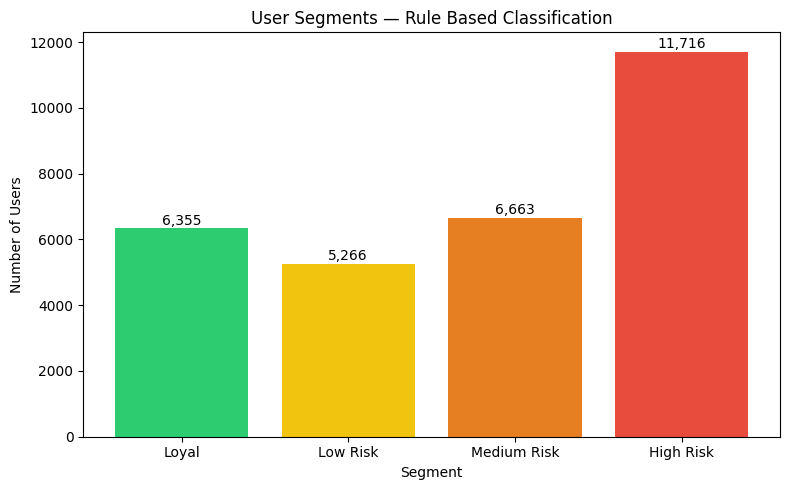

In [12]:
seg_counts = df['segment'].value_counts().reindex(['Loyal', 'Low Risk', 'Medium Risk', 'High Risk'])

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(seg_counts.index, seg_counts.values, color=colors)
plt.title('User Segments — Rule Based Classification')
plt.xlabel('Segment')
plt.ylabel('Number of Users')

for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

 **39% of users are High Risk** — 11,716 users show frequent payment 
   delays and low repayment. This is the primary target for early 
   intervention by the bank.

### Default rate per segment

In [13]:
default_by_seg = df.groupby('segment')['default_payment_next_month'].mean().mul(100).round(2)
default_by_seg = default_by_seg.reindex(['Loyal', 'Low Risk', 'Medium Risk', 'High Risk'])
print(default_by_seg)

segment
Loyal          12.18
Low Risk       15.19
Medium Risk    21.87
High Risk      30.77
Name: default_payment_next_month, dtype: float64


 Default rate rises cleanly from Loyal to High Risk.
- Loyal → 12% default rate
- Low Risk → 15%
- Medium Risk → 22%
- High Risk → 31%
 

**Even Loyal users default at 12%** — no segment is completely safe, 
   suggesting external factors (job loss, emergencies) affect even 
   disciplined payers.

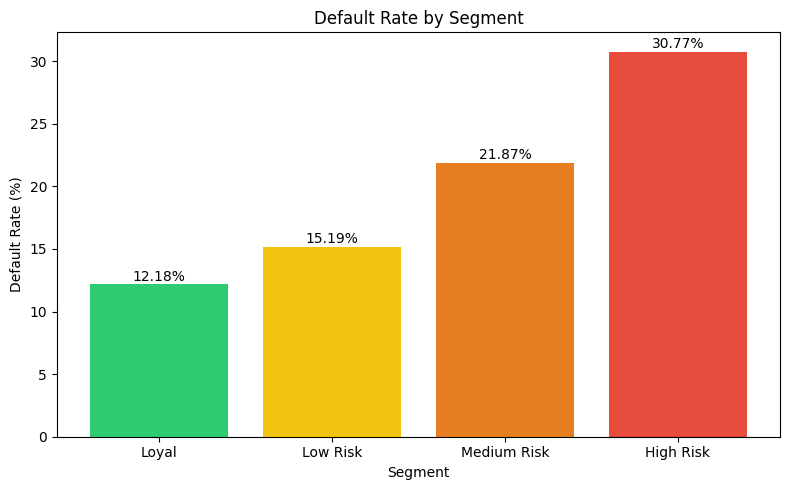

In [14]:
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(default_by_seg.index, default_by_seg.values, color=colors)
plt.title('Default Rate by Segment')
plt.xlabel('Segment')
plt.ylabel('Default Rate (%)')

for bar, val in zip(bars, default_by_seg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Segmentation is validated** — default rate rises consistently from 
   12% (Loyal) to 31% (High Risk), confirming the rules correctly 
   separate risky from healthy users.